# Комп'ютерний практикум 9: рівняння Пуассона для зображень
1. відновлення зображення за його полем градієнтів;
2. безшовне вставлення образу в інше зображення;
3. необов'язкове: паралельна версія відновлення;
4. необов'язкове: паралельна версія безшовного вставлення.

Для кожної основної задачі є два способи розв'язання:

- метод Зейделя/SOR;
- `scipy.sparse.linalg.spsolve`.

Паралельна частина зроблена як red-black Gauss-Seidel через `numba.prange`.


In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path
from time import perf_counter
from scipy.sparse import coo_matrix
from scipy.sparse.linalg import spsolve
try:
    from numba import njit, prange
    NUMBA_AVAILABLE = True
except Exception:
    NUMBA_AVAILABLE = False

In [20]:
NEIGHBORS = [(-1, 0), (1, 0), (0, -1), (0, 1)]

def to_float01(img):
    arr = np.asarray(img, dtype=np.float64)
    if arr.max() > 1.0:
        arr = arr / 255.0
    if arr.ndim == 2:
        arr = arr[..., None]
    return np.clip(arr, 0, 1)

def read_rgb(path, size=None):
    im = Image.open(path).convert('RGB')
    if size is not None:
        im = im.resize((size[1], size[0]), Image.Resampling.LANCZOS)
    return to_float01(im)

def save_rgb(path, arr):
    arr8 = (np.clip(arr, 0, 1) * 255).astype(np.uint8)
    Image.fromarray(arr8.squeeze()).save(path)

def make_demo_target(size=(160, 160), variant=0):
    H, W = size
    y, x = np.mgrid[0:H, 0:W]
    xn = x / max(W - 1, 1)
    yn = y / max(H - 1, 1)
    waves = 0.5 + 0.5 * np.sin((variant + 2) * np.pi * xn) * np.cos((variant + 1) * np.pi * yn)
    target = np.dstack([
        0.15 + 0.75 * xn,
        0.20 + 0.65 * yn,
        0.20 + 0.55 * waves,
    ])
    # декоративний прямокутник і коло, щоб були помітні шви
    target[H//5:2*H//5, W//8:W//3, 0] = 0.95
    target[H//5:2*H//5, W//8:W//3, 1] *= 0.35
    cy, cx = int(0.70 * H), int(0.72 * W)
    rr = (y - cy) ** 2 + (x - cx) ** 2
    target[rr < (min(H, W) * 0.13) ** 2, 2] = 0.95
    return np.clip(target, 0, 1)

def make_demo_source(size=(70, 70), variant=0):
    H, W = size
    y, x = np.mgrid[0:H, 0:W]
    xn = x / max(W - 1, 1)
    yn = y / max(H - 1, 1)
    r = np.sqrt((xn - 0.5) ** 2 + (yn - 0.5) ** 2)
    stripes = 0.5 + 0.5 * np.sin((10 + variant) * np.pi * xn + (5 + variant) * np.pi * yn)
    source = np.dstack([
        0.85 * np.exp(-5 * r) + 0.15 * stripes,
        0.25 + 0.65 * stripes,
        0.15 + 0.70 * (1 - r),
    ])
    return np.clip(source, 0, 1)

def make_ellipse_mask(size, margin=4):
    H, W = size
    y, x = np.mgrid[0:H, 0:W]
    cy, cx = (H - 1) / 2, (W - 1) / 2
    ay = max((H - 2 * margin) / 2, 1)
    ax = max((W - 2 * margin) / 2, 1)
    mask = ((y - cy) / ay) ** 2 + ((x - cx) / ax) ** 2 <= 1
    mask[:margin, :] = False
    mask[-margin:, :] = False
    mask[:, :margin] = False
    mask[:, -margin:] = False
    return mask

def load_or_make_demo(target_path='target.jpg', source_path='source.jpg', mask_path=None, target_size=(180, 180)):
    target_file = Path(target_path)
    source_file = Path(source_path)
    if target_file.exists() and source_file.exists():
        target = read_rgb(target_file, target_size)
        # Джерело робимо меншим за цільове зображення
        src_size = (target_size[0] // 3, target_size[1] // 3)
        source = read_rgb(source_file, src_size)
    else:
        target = make_demo_target(target_size)
        source = make_demo_source((target_size[0] // 3, target_size[1] // 3))

    if mask_path is not None and Path(mask_path).exists():
        mask_img = Image.open(mask_path).convert('L').resize((source.shape[1], source.shape[0]), Image.Resampling.NEAREST)
        mask_patch = np.asarray(mask_img) > 127
        # маска не повинна торкатися меж фрагмента
        mask_patch[[0, -1], :] = False
        mask_patch[:, [0, -1]] = False
    else:
        mask_patch = make_ellipse_mask(source.shape[:2], margin=max(3, min(source.shape[:2]) // 20))
    return target, source, mask_patch

def shifted_for_neighbor(a, di, dj):
    out = np.zeros_like(a)
    if di == 1:
        out[:-1, :] = a[1:, :]
    elif di == -1:
        out[1:, :] = a[:-1, :]
    elif dj == 1:
        out[:, :-1] = a[:, 1:]
    elif dj == -1:
        out[:, 1:] = a[:, :-1]
    else:
        raise ValueError('Потрібен один із 4 сусідів')
    return out

def rhs_from_image_gradients(image):
    img = to_float01(image)
    rhs = np.zeros_like(img)
    for di, dj in NEIGHBORS:
        rhs += img - shifted_for_neighbor(img, di, dj)
    return rhs

def rectangular_inner_mask(shape):
    H, W = shape
    mask = np.zeros((H, W), dtype=bool)
    mask[1:-1, 1:-1] = True
    return mask

def build_poisson_matrix(mask):
    H, W = mask.shape
    coords = np.argwhere(mask)
    n = len(coords)
    index = -np.ones((H, W), dtype=np.int32)
    index[mask] = np.arange(n, dtype=np.int32)

    rows, cols, data = [], [], []
    for row, (i, j) in enumerate(coords):
        rows.append(row); cols.append(row); data.append(4.0)
        for di, dj in NEIGHBORS:
            ni, nj = i + di, j + dj
            if mask[ni, nj]:
                rows.append(row); cols.append(index[ni, nj]); data.append(-1.0)
    A = coo_matrix((data, (rows, cols)), shape=(n, n)).tocsr()
    return A, coords, index

def make_b_vector(rhs_ch, boundary_ch, mask, coords):
    b = np.empty(len(coords), dtype=np.float64)
    for row, (i, j) in enumerate(coords):
        s = rhs_ch[i, j]
        for di, dj in NEIGHBORS:
            ni, nj = i + di, j + dj
            if not mask[ni, nj]:
                s += boundary_ch[ni, nj]
        b[row] = s
    return b

In [13]:
def solve_poisson_sparse(rhs, boundary, mask):
    rhs = np.asarray(rhs, dtype=np.float64)
    boundary = np.asarray(boundary, dtype=np.float64)
    if rhs.ndim == 2:
        rhs = rhs[..., None]
        boundary = boundary[..., None]
        squeeze = True
    else:
        squeeze = False
    A, coords, _ = build_poisson_matrix(mask)
    result = boundary.copy()
    for c in range(rhs.shape[2]):
        b = make_b_vector(rhs[..., c], boundary[..., c], mask, coords)
        x = spsolve(A, b)
        result[..., c][mask] = x
    return result[..., 0] if squeeze else np.clip(result, 0, 1)

def solve_poisson_gauss_seidel(rhs, boundary, mask, max_iter=3000, tol=1e-5, omega=1.85):
    rhs = np.asarray(rhs, dtype=np.float64)
    boundary = np.asarray(boundary, dtype=np.float64)
    if rhs.ndim == 2:
        rhs = rhs[..., None]
        boundary = boundary[..., None]
        squeeze = True
    else:
        squeeze = False

    result = boundary.copy()
    coords = np.argwhere(mask)
    last_iter = 0
    last_err = np.inf
    for c in range(rhs.shape[2]):
        x = result[..., c]
        for it in range(max_iter):
            max_delta = 0.0
            for i, j in coords:
                s = rhs[i, j, c]
                s += x[i - 1, j] if mask[i - 1, j] else boundary[i - 1, j, c]
                s += x[i + 1, j] if mask[i + 1, j] else boundary[i + 1, j, c]
                s += x[i, j - 1] if mask[i, j - 1] else boundary[i, j - 1, c]
                s += x[i, j + 1] if mask[i, j + 1] else boundary[i, j + 1, c]
                new_val = 0.25 * s
                relaxed = (1.0 - omega) * x[i, j] + omega * new_val
                delta = abs(relaxed - x[i, j])
                if delta > max_delta:
                    max_delta = delta
                x[i, j] = relaxed
            last_iter = max(last_iter, it + 1)
            last_err = max_delta
            if max_delta < tol:
                break
        result[..., c] = x
    return (result[..., 0] if squeeze else np.clip(result, 0, 1)), last_iter, last_err

if NUMBA_AVAILABLE:
    @njit(parallel=True)
    def _rbgs_gray(rhs, boundary, mask, x, max_iter, tol):
        H, W = rhs.shape
        denom = 1.0
        count = 0
        for i in range(H):
            for j in range(W):
                if mask[i, j]:
                    count += 1
        if count > 0:
            denom = count

        final_err = 0.0
        for it in range(max_iter):
            err = 0.0
            for parity in range(2):
                for i in prange(1, H - 1):
                    for j in range(1, W - 1):
                        if mask[i, j] and ((i + j) & 1) == parity:
                            up = x[i - 1, j] if mask[i - 1, j] else boundary[i - 1, j]
                            down = x[i + 1, j] if mask[i + 1, j] else boundary[i + 1, j]
                            left = x[i, j - 1] if mask[i, j - 1] else boundary[i, j - 1]
                            right = x[i, j + 1] if mask[i, j + 1] else boundary[i, j + 1]
                            new_val = 0.25 * (rhs[i, j] + up + down + left + right)
                            diff = new_val - x[i, j]
                            x[i, j] = new_val
                            err += diff * diff
            final_err = np.sqrt(err / denom)
            if final_err < tol:
                return it + 1, final_err
        return max_iter, final_err

def solve_poisson_rbgs_parallel(rhs, boundary, mask, max_iter=4000, tol=1e-5):
    if not NUMBA_AVAILABLE:
        raise ImportError('Для паралельної версії встановіть numba: conda install numba')
    rhs = np.asarray(rhs, dtype=np.float64)
    boundary = np.asarray(boundary, dtype=np.float64)
    if rhs.ndim == 2:
        rhs = rhs[..., None]
        boundary = boundary[..., None]
        squeeze = True
    else:
        squeeze = False
    result = boundary.copy()
    last_iter = 0
    last_err = np.inf
    for c in range(rhs.shape[2]):
        x = result[..., c].copy()
        it, err = _rbgs_gray(rhs[..., c], boundary[..., c], mask, x, max_iter, tol)
        result[..., c] = x
        last_iter = max(last_iter, it)
        last_err = max(last_err if np.isfinite(last_err) else err, err)
    return (result[..., 0] if squeeze else np.clip(result, 0, 1)), last_iter, last_err

def warmup_numba():
    if NUMBA_AVAILABLE:
        b = np.zeros((12, 12), dtype=np.float64)
        bd = np.zeros((12, 12), dtype=np.float64)
        m = rectangular_inner_mask((12, 12))
        x = bd.copy()
        _rbgs_gray(b, bd, m, x, 2, 1e-6)

def reconstruct_from_gradient_field(image, method='sparse', **kwargs):
    image = to_float01(image)
    boundary = image.copy()
    mask = rectangular_inner_mask(image.shape[:2])
    rhs = rhs_from_image_gradients(image)
    if method == 'sparse':
        return solve_poisson_sparse(rhs, boundary, mask)
    if method == 'seidel':
        return solve_poisson_gauss_seidel(rhs, boundary, mask, **kwargs)[0]
    if method == 'parallel':
        return solve_poisson_rbgs_parallel(rhs, boundary, mask, **kwargs)[0]
    raise ValueError('method має бути sparse, seidel або parallel')


In [21]:

def put_source_on_canvas(target, source, mask_patch, top_left):
    H, W, C = target.shape
    h, w, _ = source.shape
    y0, x0 = top_left
    if y0 < 1 or x0 < 1 or y0 + h >= H - 1 or x0 + w >= W - 1:
        raise ValueError('Фрагмент має бути всередині target і не торкатися межі зображення')
    source_canvas = np.zeros_like(target)
    source_canvas[y0:y0+h, x0:x0+w] = source
    mask = np.zeros((H, W), dtype=bool)
    mask[y0:y0+h, x0:x0+w] = mask_patch
    # маска не повинна включати межу всього зображення
    mask[[0, -1], :] = False
    mask[:, [0, -1]] = False
    return source_canvas, mask

def rhs_for_cloning(target, source_canvas, mask, mixed=False):
    rhs = np.zeros_like(target, dtype=np.float64)
    for di, dj in NEIGHBORS:
        s_q = shifted_for_neighbor(source_canvas, di, dj)
        t_q = shifted_for_neighbor(target, di, dj)
        grad_s = source_canvas - s_q
        grad_t = target - t_q
        if mixed:
            mag_s = np.linalg.norm(grad_s, axis=2)
            mag_t = np.linalg.norm(grad_t, axis=2)
            chosen = np.where((mag_s >= mag_t)[..., None], grad_s, grad_t)
        else:
            chosen = grad_s
        rhs += chosen
    return rhs

def seamless_clone(target, source, mask_patch, top_left, method='sparse', mixed=False, **kwargs):
    target = to_float01(target)
    source = to_float01(source)
    source_canvas, mask = put_source_on_canvas(target, source, mask_patch, top_left)
    rhs = rhs_for_cloning(target, source_canvas, mask, mixed=mixed)
    boundary = target.copy()
    if method == 'sparse':
        return solve_poisson_sparse(rhs, boundary, mask)
    if method == 'seidel':
        return solve_poisson_gauss_seidel(rhs, boundary, mask, **kwargs)[0]
    if method == 'parallel':
        return solve_poisson_rbgs_parallel(rhs, boundary, mask, **kwargs)[0]
    raise ValueError('method має бути sparse, seidel або parallel')

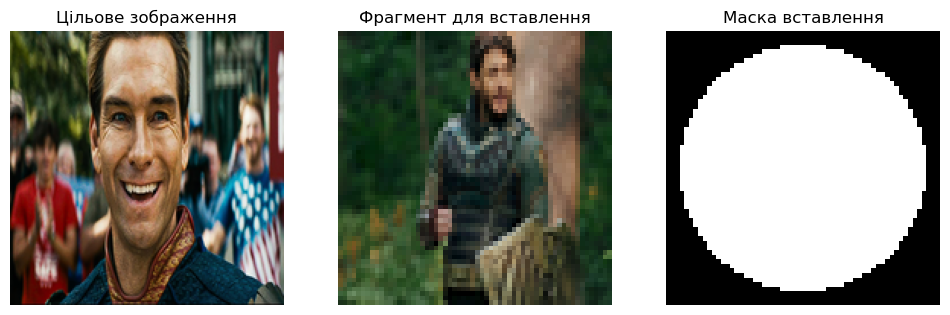

In [14]:
TARGET_PATH = 'target.jpg'
SOURCE_PATH = 'source.jpg'
MASK_PATH = None      # наприклад, 'mask.png'

target, source, mask_patch = load_or_make_demo(
    target_path=TARGET_PATH,
    source_path=SOURCE_PATH,
    mask_path=MASK_PATH,
    target_size=(180, 180)
)

top_left = (target.shape[0] // 3, target.shape[1] // 3)  # позиція вставлення: (y, x)

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1); plt.imshow(target); plt.title('Цільове зображення'); plt.axis('off')
plt.subplot(1, 3, 2); plt.imshow(source); plt.title('Фрагмент для вставлення'); plt.axis('off')
plt.subplot(1, 3, 3); plt.imshow(mask_patch, cmap='gray'); plt.title('Маска вставлення'); plt.axis('off')
plt.show()


Завдання 1: відновлення зображення за полем градієнтів

In [22]:
warmup_numba()

max_iter = 1500
tol = 1e-5
omega = 1.85

t0 = perf_counter()
rec_seidel = reconstruct_from_gradient_field(target, method='seidel', max_iter=max_iter, tol=tol, omega=omega)
time_rec_seidel = perf_counter() - t0

t0 = perf_counter()
rec_sparse = reconstruct_from_gradient_field(target, method='sparse')
time_rec_sparse = perf_counter() - t0

rec_parallel = None
time_rec_parallel = None
if NUMBA_AVAILABLE:
    t0 = perf_counter()
    rec_parallel = reconstruct_from_gradient_field(target, method='parallel', max_iter=max_iter, tol=tol)
    time_rec_parallel = perf_counter() - t0

print(f'Відновлення, Зейдель/SOR: {time_rec_seidel:.4f} с')
print(f'Відновлення, scipy.sparse.linalg.spsolve: {time_rec_sparse:.4f} с')
if time_rec_parallel is not None:
    print(f'Відновлення, паралельний red-black GS numba: {time_rec_parallel:.4f} с')


Відновлення, Зейдель/SOR: 0.1982 с
Відновлення, scipy.sparse.linalg.spsolve: 0.4238 с
Відновлення, паралельний red-black GS numba: 0.0072 с


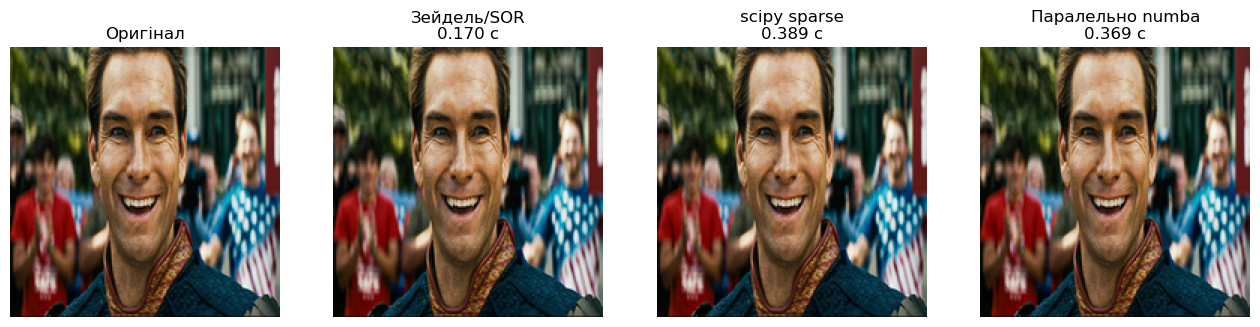

MAE Зейдель/SOR: 6.951315456766639e-17
MAE scipy sparse: 2.4406384362007264e-14
MAE parallel: 8.948728103980563e-18


In [16]:
ncols = 4 if rec_parallel is not None else 3
plt.figure(figsize=(4*ncols, 4))
plt.subplot(1, ncols, 1); plt.imshow(target); plt.title('Оригінал'); plt.axis('off')
plt.subplot(1, ncols, 2); plt.imshow(rec_seidel); plt.title(f'Зейдель/SOR\n{time_rec_seidel:.3f} с'); plt.axis('off')
plt.subplot(1, ncols, 3); plt.imshow(rec_sparse); plt.title(f'scipy sparse\n{time_rec_sparse:.3f} с'); plt.axis('off')
if rec_parallel is not None:
    plt.subplot(1, ncols, 4); plt.imshow(rec_parallel); plt.title(f'Паралельно numba\n{time_rec_parallel:.3f} с'); plt.axis('off')
plt.show()

# Середня абсолютна похибка відносно оригіналу
print('MAE Зейдель/SOR:', np.mean(np.abs(rec_seidel - target)))
print('MAE scipy sparse:', np.mean(np.abs(rec_sparse - target)))
if rec_parallel is not None:
    print('MAE parallel:', np.mean(np.abs(rec_parallel - target)))


Завдання 2: безшовне вставлення образу

In [23]:
MIXED_GRADIENTS = False  # поставте True для змішування градієнтів

t0 = perf_counter()
clone_seidel = seamless_clone(target, source, mask_patch, top_left, method='seidel', mixed=MIXED_GRADIENTS, max_iter=max_iter, tol=tol, omega=omega)
time_clone_seidel = perf_counter() - t0

t0 = perf_counter()
clone_sparse = seamless_clone(target, source, mask_patch, top_left, method='sparse', mixed=MIXED_GRADIENTS)
time_clone_sparse = perf_counter() - t0

clone_parallel = None
time_clone_parallel = None
if NUMBA_AVAILABLE:
    t0 = perf_counter()
    clone_parallel = seamless_clone(target, source, mask_patch, top_left, method='parallel', mixed=MIXED_GRADIENTS, max_iter=max_iter, tol=tol)
    time_clone_parallel = perf_counter() - t0

print(f'Клонування, Зейдель/SOR: {time_clone_seidel:.4f} с')
print(f'Клонування, scipy.sparse.linalg.spsolve: {time_clone_sparse:.4f} с')
if time_clone_parallel is not None:
    print(f'Клонування, паралельний red-black GS numba: {time_clone_parallel:.4f} с')


Клонування, Зейдель/SOR: 1.5073 с
Клонування, scipy.sparse.linalg.spsolve: 0.0239 с
Клонування, паралельний red-black GS numba: 0.0741 с


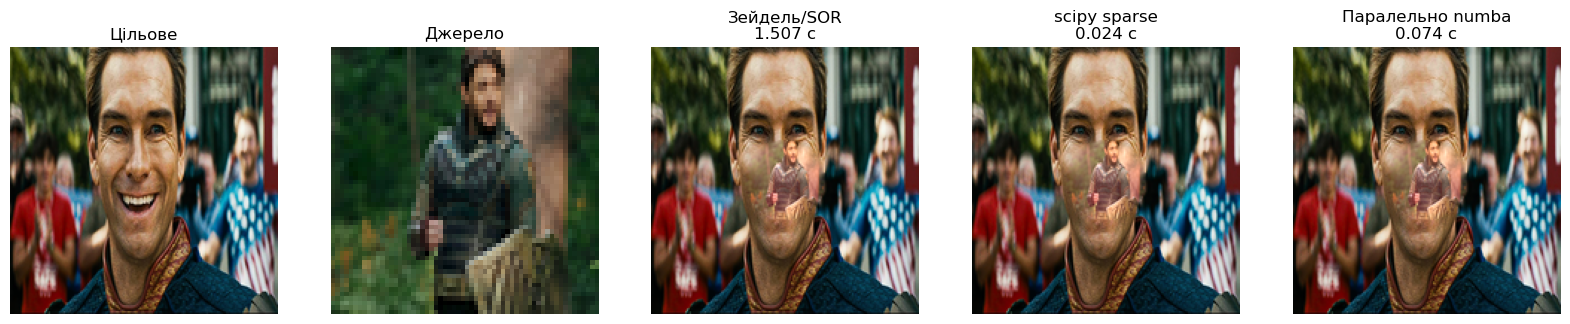

In [24]:
ncols = 5 if clone_parallel is not None else 4
plt.figure(figsize=(4*ncols, 4))
plt.subplot(1, ncols, 1); plt.imshow(target); plt.title('Цільове'); plt.axis('off')
plt.subplot(1, ncols, 2); plt.imshow(source); plt.title('Джерело'); plt.axis('off')
plt.subplot(1, ncols, 3); plt.imshow(clone_seidel); plt.title(f'Зейдель/SOR\n{time_clone_seidel:.3f} с'); plt.axis('off')
plt.subplot(1, ncols, 4); plt.imshow(clone_sparse); plt.title(f'scipy sparse\n{time_clone_sparse:.3f} с'); plt.axis('off')
if clone_parallel is not None:
    plt.subplot(1, ncols, 5); plt.imshow(clone_parallel); plt.title(f'Паралельно numba\n{time_clone_parallel:.3f} с'); plt.axis('off')
plt.show()


Порівняння часу на різних зображеннях

In [25]:
def benchmark_one(size, variant=0, max_iter_bench=700, tol_bench=5e-5):
    target_b = make_demo_target((size, size), variant=variant)
    source_b = make_demo_source((size // 3, size // 3), variant=variant)
    mask_b = make_ellipse_mask(source_b.shape[:2], margin=max(3, size // 60))
    top_left_b = (size // 3, size // 3)

    rows = []

    # Завдання 1: відновлення
    t0 = perf_counter()
    _ = reconstruct_from_gradient_field(target_b, method='seidel', max_iter=max_iter_bench, tol=tol_bench, omega=omega)
    rows.append({'Задача': 'Відновлення', 'Розмір': f'{size}x{size}', 'N': size, 'Метод': 'Зейдель/SOR', 'Час, с': perf_counter() - t0})

    t0 = perf_counter()
    _ = reconstruct_from_gradient_field(target_b, method='sparse')
    rows.append({'Задача': 'Відновлення', 'Розмір': f'{size}x{size}', 'N': size, 'Метод': 'scipy sparse', 'Час, с': perf_counter() - t0})

    if NUMBA_AVAILABLE:
        t0 = perf_counter()
        _ = reconstruct_from_gradient_field(target_b, method='parallel', max_iter=max_iter_bench, tol=tol_bench)
        rows.append({'Задача': 'Відновлення', 'Розмір': f'{size}x{size}', 'N': size, 'Метод': 'parallel numba', 'Час, с': perf_counter() - t0})

    # Завдання 2: клонування
    t0 = perf_counter()
    _ = seamless_clone(target_b, source_b, mask_b, top_left_b, method='seidel', mixed=False, max_iter=max_iter_bench, tol=tol_bench, omega=omega)
    rows.append({'Задача': 'Клонування', 'Розмір': f'{size}x{size}', 'N': size, 'Метод': 'Зейдель/SOR', 'Час, с': perf_counter() - t0})

    t0 = perf_counter()
    _ = seamless_clone(target_b, source_b, mask_b, top_left_b, method='sparse', mixed=False)
    rows.append({'Задача': 'Клонування', 'Розмір': f'{size}x{size}', 'N': size, 'Метод': 'scipy sparse', 'Час, с': perf_counter() - t0})

    if NUMBA_AVAILABLE:
        t0 = perf_counter()
        _ = seamless_clone(target_b, source_b, mask_b, top_left_b, method='parallel', mixed=False, max_iter=max_iter_bench, tol=tol_bench)
        rows.append({'Задача': 'Клонування', 'Розмір': f'{size}x{size}', 'N': size, 'Метод': 'parallel numba', 'Час, с': perf_counter() - t0})

    return rows

sizes = [64, 96, 128, 160]
all_rows = []
for k, size in enumerate(sizes):
    print('benchmark:', size)
    all_rows.extend(benchmark_one(size, variant=k))

df_times = pd.DataFrame(all_rows)
display(df_times)


benchmark: 64
benchmark: 96
benchmark: 128
benchmark: 160


,Задача,Розмір,N,Метод,"Час, с"
0,Відновлення,64x64,64,Зейдель/SOR,0.036497
1,Відновлення,64x64,64,scipy sparse,0.045409
2,Відновлення,64x64,64,parallel numba,0.000532
3,Клонування,64x64,64,Зейдель/SOR,0.053779
4,Клонування,64x64,64,scipy sparse,0.001688
5,Клонування,64x64,64,parallel numba,0.006208
6,Відновлення,96x96,96,Зейдель/SOR,0.047238
7,Відновлення,96x96,96,scipy sparse,0.088899
8,Відновлення,96x96,96,parallel numba,0.000412
9,Клонування,96x96,96,Зейдель/SOR,0.166895


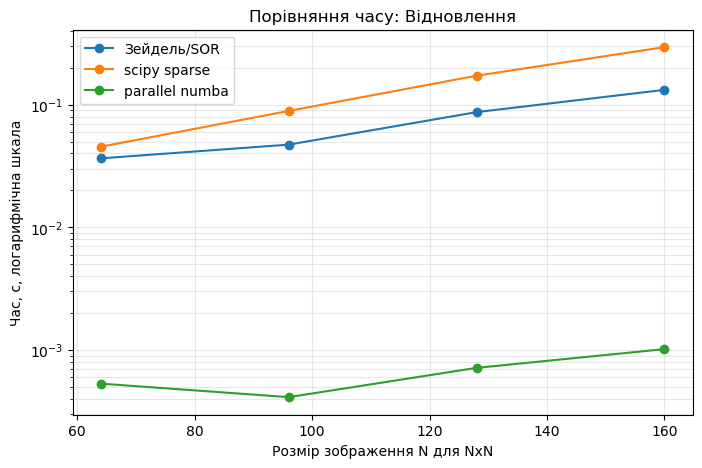

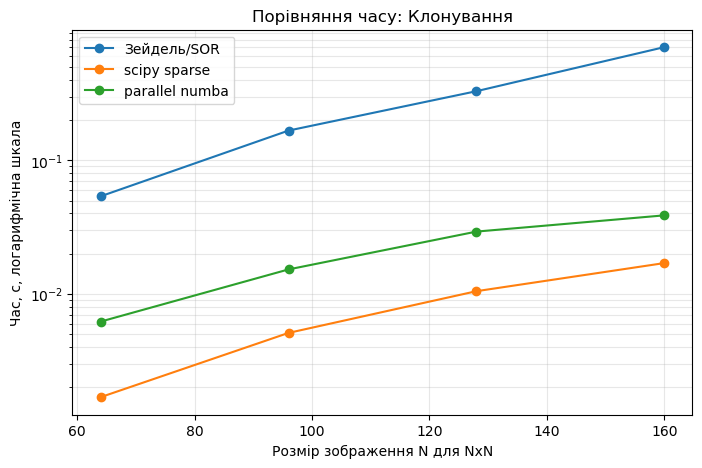

In [26]:
for task in df_times['Задача'].unique():
    plt.figure(figsize=(8, 5))
    part = df_times[df_times['Задача'] == task]
    for method in part['Метод'].unique():
        cur = part[part['Метод'] == method].sort_values('N')
        plt.plot(cur['N'], cur['Час, с'], marker='o', label=method)
    plt.yscale('log')
    plt.xlabel('Розмір зображення N для NxN')
    plt.ylabel('Час, с, логарифмічна шкала')
    plt.title(f'Порівняння часу: {task}')
    plt.grid(True, which='both', alpha=0.3)
    plt.legend()
    plt.show()


In [27]:
save_rgb('result_reconstruction_seidel.png', rec_seidel)
save_rgb('result_reconstruction_sparse.png', rec_sparse)
save_rgb('result_clone_seidel.png', clone_seidel)
save_rgb('result_clone_sparse.png', clone_sparse)
if rec_parallel is not None:
    save_rgb('result_reconstruction_parallel.png', rec_parallel)
if clone_parallel is not None:
    save_rgb('result_clone_parallel.png', clone_parallel)

df_times.to_csv('poisson_timing_results.csv', index=False)
